<a href="https://www.kaggle.com/code/harukimurai/the-power-of-store-maturity?scriptVersionId=305898002" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Store Sales Forecasting: The Power of "Store Maturity"

---

# **Overview**

This notebook presents a robust and practical approach to the "Store Sales - Time Series Forecasting" competition.

While some solutions rely on external economic indicators that might not be available in real-time business scenarios (such as future oil prices), this model focuses on internal store dynamics and temporal features.

## Key Highlight: `log_days_elapsed`
The core contribution of this work is the introduction of **Store Maturity**—represented by the feature `log_days_elapsed`.  

By calculating the time passed since each store's first appearance in the dataset, we capture the organic growth and stabilization of retail outlets.

Results show that this single feature significantly boosts model performance, ranking as the second most important feature after product category (`family`).

## Direction Principles
1. **Practicality First**:  

    We intentionally exclude future-dependent features (like daily oil prices) to simulate a real-world forecasting environment where such data is unavailable at the time of prediction.

2. **Feature Efficiency**:  

    Instead of a "kitchen sink" approach, we use a curated set of 17 features that capture seasonality, promotion impact, and store-specific evolution.

3. **Simplicity over Complexity**:  

    We utilize a well-tuned LightGBM model to demonstrate that deep feature engineering often outweighs complex model stacking.  
---

# **Settings**

In [1]:
# --- 1. Upload API Key ---
# from google.colab import files
# print("Please upload your kaggle.json file")
# files.upload() # Select your kaggle.json here

# --- 2. Setup Kaggle API ---
# Create directory and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# --- 3. Download and Unzip ---
# Download the dataset from Kaggle
!kaggle competitions download -c store-sales-time-series-forecasting
# Extract all CSV files
!unzip -o store-sales-time-series-forecasting.zip

# --- 4. Verify Files ---
# List files to confirm everything is there
import os
print(os.listdir())

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
100%|██████████████████████████████████████| 21.4M/21.4M [00:01<00:00, 13.7MB/s]

Archive:  store-sales-time-series-forecasting.zip
  inflating: holidays_events.csv     
  inflating: oil.csv                 
  inflating: sample_submission.csv   
  inflating: stores.csv              
  inflating: test.csv                
  inflating: train.csv               
  inflating: transactions.csv        
['stores.csv', 'sample_submission.csv', 'test.csv', '__notebook__.ipynb', 'train.csv', 'transactions.csv', 'holidays_events.csv', 'oil.csv', 'store-sales-time-series-forecasting.zip']


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Explanatory Data Analysis**

## Target Sales & Seasonality

Analyzing the daily sales:  

* **New Year's Day (Jan 1st) Flag:**  

  Visualization shows a consistent zero-sales gap every January 1st due to nationwide store closures.  
  A dedicated binary flag (`is_jan_1st`) was added to prevent the model from struggling to learn this outlier.

* **Weekly Seasonality:**  

  By zooming into the 2017 data, we observe a 7-day cycle where sales consistently peak on weekends.  
  This justifies the inclusion of `dayofweek` and `is_weekend` to capture the rhythmic fluctuations in consumer behavior.

* **Log Transformation:**  

  The target variable `sales` exhibits a right-skewed distribution with large variance.  
  We applied `np.log1p` to stabilize the variance and align with the RMSLE evaluation metric used in this competition.

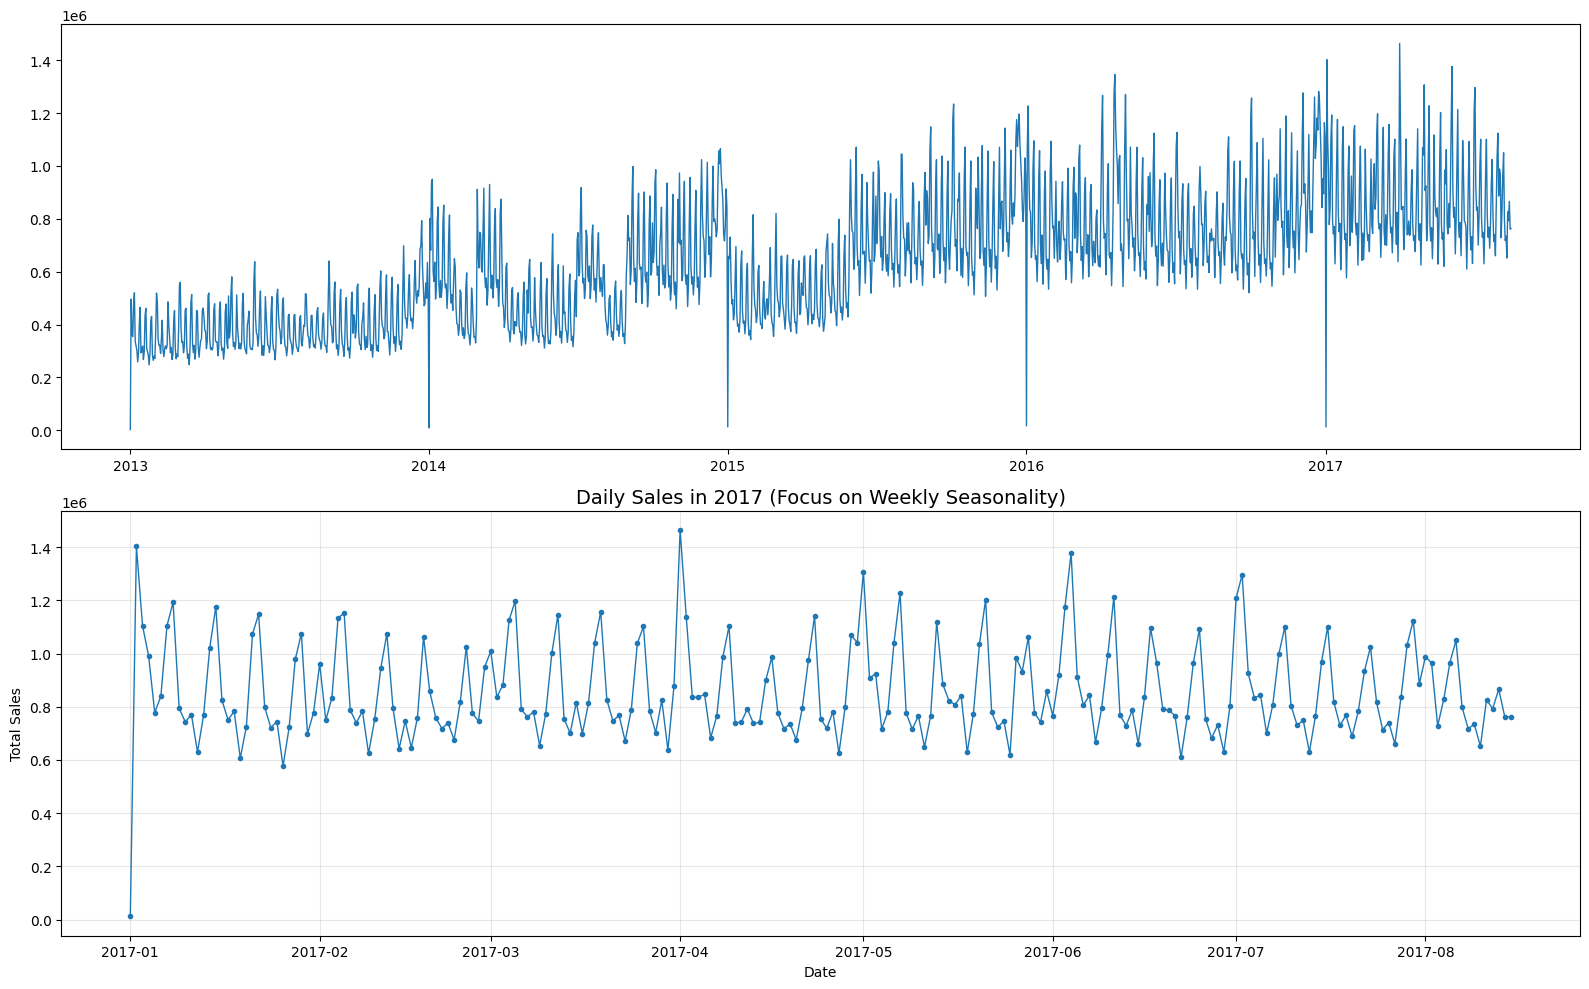

In [3]:
train = pd.read_csv('train.csv', parse_dates=['date'])

# Aggregate Sales by Date
daily_sales = train.groupby('date')['sales'].agg(['sum', 'mean']).reset_index()

# Visualization
plt.figure(figsize=(16, 10))

# Subplot 1: Total Sales (All Stores)
plt.subplot(2, 1, 1)
plt.plot(daily_sales['date'], daily_sales['sum'], color='tab:blue', linewidth=1)

# Subplot 2: Zoom in on a specific period to see Seasonality (2017)
plt.subplot(2, 1, 2)
recent_sales = daily_sales[daily_sales['date'] >= '2017-01-01']
plt.plot(recent_sales['date'], recent_sales['sum'], color='tab:blue', marker='o', markersize=3, linewidth=1)
plt.title('Daily Sales in 2017 (Focus on Weekly Seasonality)', fontsize=14)
plt.ylabel('Total Sales')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Oil Price & Practicality

By overlaying the daily oil price with total sales, we evaluated the macroeconomic impact on retail behavior:

* **Weak Daily Correlation:**  

  The visualization reveals that micro-fluctuations in oil prices do not have an immediate or direct impact on daily grocery sales.  
  While oil is a backbone of Ecuador's economy, its effect on retail is likely more structural and long-term rather than a day-to-day driver.

* **Avoiding "Future Data" (Practicality):**  

  In this competition, oil prices for the test period are provided.  
  However, in a real-world business scenario, future oil prices are unknown at the time of prediction.  
  Using them would create a model that is impossible to deploy in a true production environment.

* **Model Decision:**  

  To ensure our model remains **practical and robust**, we intentionally excluded `dcoilwtico` from our features.  

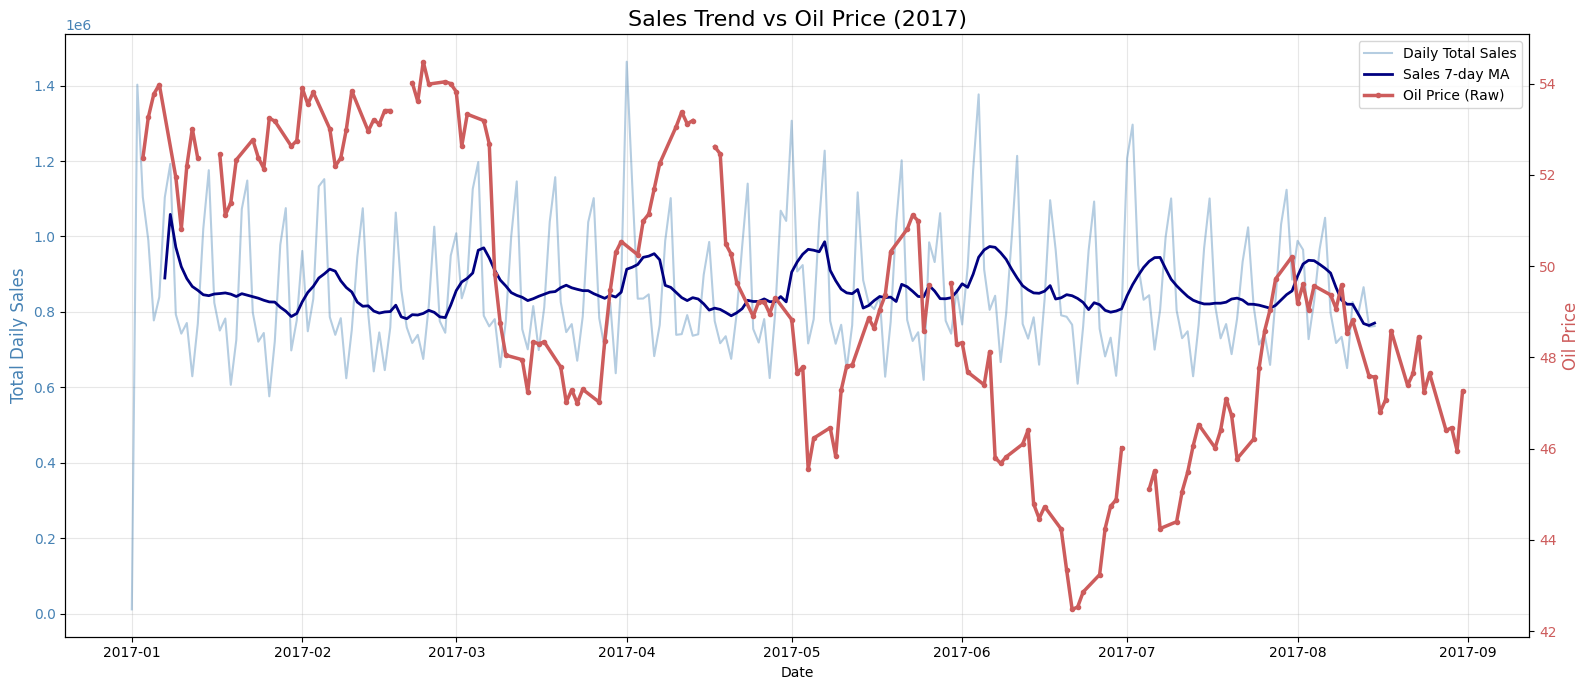

In [4]:
# Prepare data for 2017
oil = pd.read_csv('oil.csv', parse_dates=['date'])
start_date = '2017-01-01'
oil_2017 = oil[oil['date'] >= start_date].copy()

# Aggregate sales to daily totals
train_2017 = train[train['date'] >= start_date].groupby('date')['sales'].sum().reset_index()

# Visualization
fig, ax1 = plt.subplots(figsize=(16, 7))

# Left Axis: Total Daily Sales
color_sales = 'steelblue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Daily Sales', color=color_sales, fontsize=12)
# Plotting daily sales with alpha for better visibility of the moving average
ax1.plot(train_2017['date'], train_2017['sales'], color=color_sales, alpha=0.4, label='Daily Total Sales')
ax1.tick_params(axis='y', labelcolor=color_sales)

# Overlay 7-day moving average to highlight the trend
ax1.plot(train_2017['date'], train_2017['sales'].rolling(7).mean(),
         color='navy', linewidth=2, label='Sales 7-day MA')

# Right Axis: Oil Price
ax2 = ax1.twinx()
color_oil = 'indianred'
ax2.set_ylabel('Oil Price', color=color_oil, fontsize=12)
# Plotting raw oil price (contains gaps/NaNs)
ax2.plot(oil_2017['date'], oil_2017['dcoilwtico'], color=color_oil, linewidth=2.5, marker='o', markersize=3, label='Oil Price (Raw)')
ax2.tick_params(axis='y', labelcolor=color_oil)

# Set Title and Grid
plt.title('Sales Trend vs Oil Price (2017)', fontsize=16)
ax1.grid(True, alpha=0.3)

# Combine legends and place it at the top right
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

## Date & Events

Retail sales are deeply influenced by the calendar:  

* **Categorizing Day Types (`h_label`):**  

  As seen in the "Average Sales by Holiday/Day Type" plot, **Transfer Holidays** and **Normal Weekends** show much higher sales than Normal Weekdays.  

  We included `dayofweek` and `is_weekend` because weekends consistently outperform weekdays. Furthermore, we categorized holidays based on whether they fall on a weekday or weekend (`3_Weekday Holiday` vs `4_Holiday on Weekend`), as their impact on consumer behavior differs.

* **Long Weekend Dynamics:**  

  The plots for "Friday Holiday + Weekend" and "Weekend + Monday Holiday" show how sales build up or sustain during long weekends.  
  Sunday sales peak when preceded by a Friday holiday, while a Monday holiday maintains high Saturday/Sunday volumes.  
  This justifies using `dayofweek` in combination with holiday flags to capture these multi-day ripples.

* **Monthly cycles (`month_cycle`):**  

  Paydays typically occur on the last day of the month.  
  Our "Monthly Cycle Impact" plot clearly shows that sales surge during the **Month-Start (1st-5th)**.  

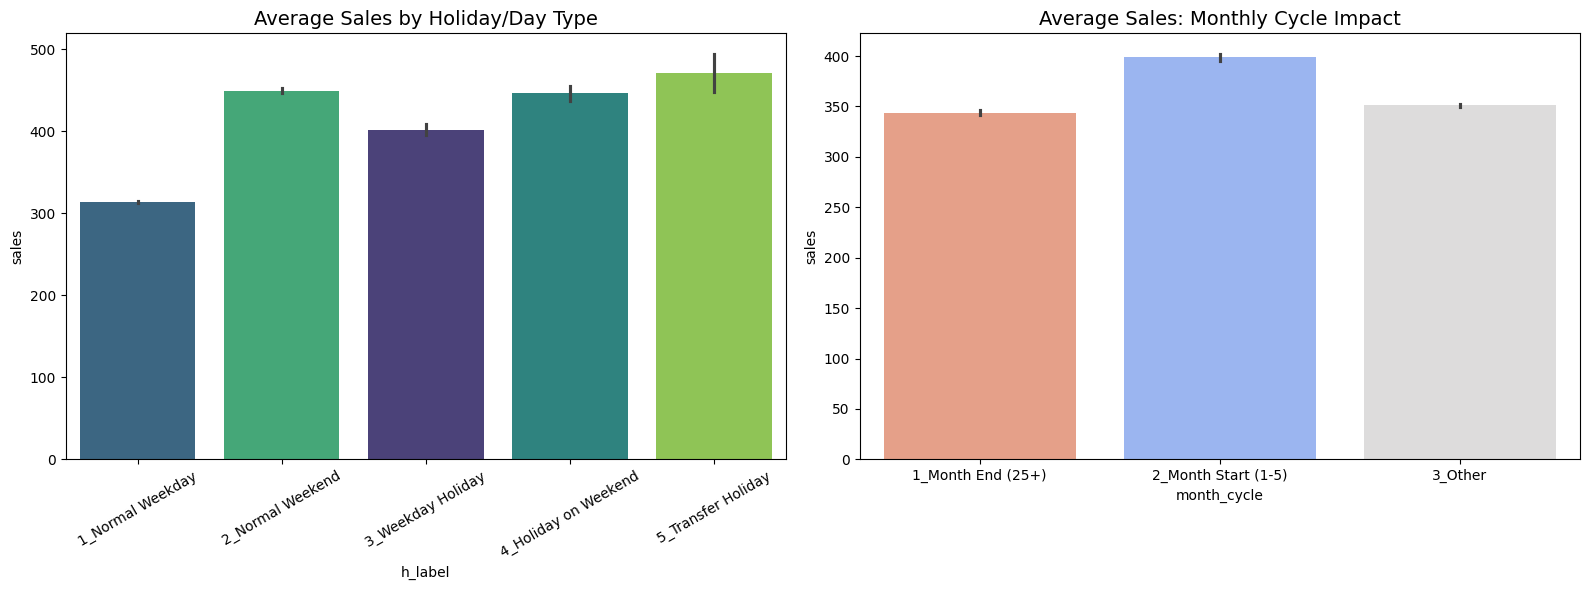

In [5]:
train = pd.read_csv('train.csv', parse_dates=['date'])
stores = pd.read_csv('stores.csv')
holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])

# Merge store info to get city and state
df = train.merge(stores, on='store_nbr', how='left')

# Advanced Holiday Labeling (5 Types)
def create_holiday_labels(df, holidays):
    # Separate holidays by locale
    nat_hols = holidays[holidays['locale'] == 'National']
    reg_hols = holidays[holidays['locale'] == 'Regional']
    loc_hols = holidays[holidays['locale'] == 'Local']

    # Initialize labels
    df['h_label'] = '1_Normal Weekday'
    df.loc[df['date'].dt.dayofweek >= 5, 'h_label'] = '2_Normal Weekend'

    # Logic to identify actual holiday impact per store
    # This is a simplified but effective way to join
    for _, row in holidays.iterrows():
        mask = (df['date'] == row['date'])
        if row['locale'] == 'National':
            pass
        elif row['locale'] == 'Regional':
            mask &= (df['state'] == row['locale_name'])
        elif row['locale'] == 'Local':
            mask &= (df['city'] == row['locale_name'])

        if row['transferred'] == True:
            # Original day that was moved (Becomes a normal day)
            df.loc[mask, 'h_label'] = '1_Normal Weekday'
        elif row['type'] == 'Transfer':
            # The destination day (Becomes a holiday)
            df.loc[mask, 'h_label'] = '5_Transfer Holiday'
        else:
            # Standard Holiday
            is_weekend = (row['date'].dayofweek >= 5)
            if is_weekend:
                df.loc[mask, 'h_label'] = '4_Holiday on Weekend'
            else:
                df.loc[mask, 'h_label'] = '3_Weekday Holiday'
    return df

df = create_holiday_labels(df, holidays)

# Monthly Cycle Feature (End of Month / Start of Month)
def create_monthly_cycle_features(df):
    # Define labels based on day of the month
    # Month End: 25th to end of month
    # Month Start: 1st to 5th
    df['month_cycle'] = '3_Other'

    day = df['date'].dt.day
    df.loc[day >= 25, 'month_cycle'] = '1_Month End (25+)'
    df.loc[day <= 5, 'month_cycle'] = '2_Month Start (1-5)'

    return df

df = create_monthly_cycle_features(df)

# Visualization
plt.figure(figsize=(16, 6))

# Subplot 1: Holiday Impact
plt.subplot(1, 2, 1)
order_h = ['1_Normal Weekday', '2_Normal Weekend', '3_Weekday Holiday', '4_Holiday on Weekend', '5_Transfer Holiday']
sns.barplot(data=df, x='h_label', y='sales', order=order_h, hue='h_label', legend=False, palette='viridis')
plt.title('Average Sales by Holiday/Day Type', fontsize=14)
plt.xticks(rotation=30)

# Subplot 2: Monthly Cycle Impact
plt.subplot(1, 2, 2)
order_m = ['1_Month End (25+)', '2_Month Start (1-5)', '3_Other']
sns.barplot(data=df, x='month_cycle', y='sales', order=order_m, hue='month_cycle', legend=False, palette='coolwarm')
plt.title('Average Sales: Monthly Cycle Impact', fontsize=14)

plt.tight_layout()
plt.show()

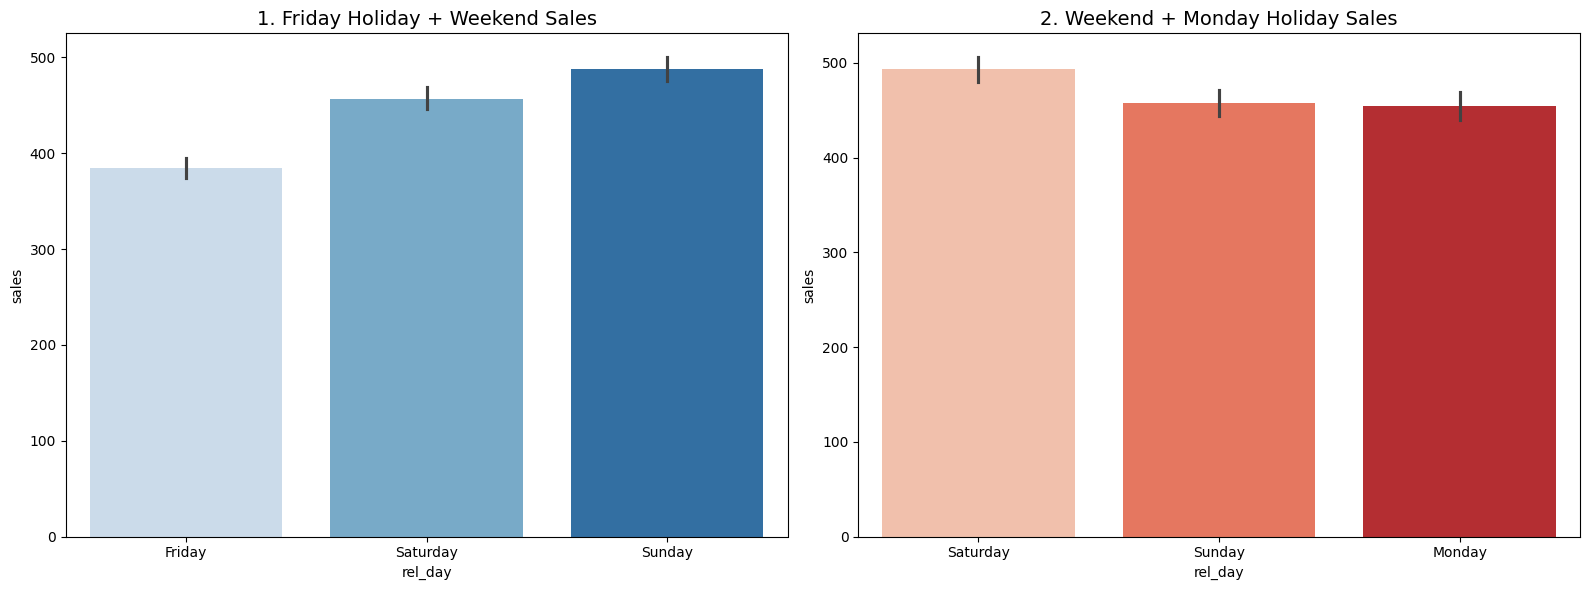

In [6]:
def analyze_long_weekends(df, holidays):
    # Filter for active National holidays only (to see clear nationwide trends)
    nat_hols = holidays[(holidays['locale'] == 'National') & (holidays['transferred'] == False)]

    # Friday Holidays: Friday(Hol), Sat, Sun
    fri_hols = nat_hols[nat_hols['date'].dt.dayofweek == 4]['date']
    fri_records = []
    for d in fri_hols:
        # Get Friday, Saturday(+1), Sunday(+2)
        target_dates = [d, d + pd.Timedelta(days=1), d + pd.Timedelta(days=2)]
        temp = df[df['date'].isin(target_dates)].copy()
        temp['rel_day'] = temp['date'].dt.day_name()
        fri_records.append(temp)

    df_fri = pd.concat(fri_records) if fri_records else pd.DataFrame()

    # Monday Holidays: Sat, Sun, Monday(Hol)
    mon_hols = nat_hols[nat_hols['date'].dt.dayofweek == 0]['date']
    mon_records = []
    for d in mon_hols:
        # Get Saturday(-2), Sunday(-1), Monday
        target_dates = [d - pd.Timedelta(days=2), d - pd.Timedelta(days=1), d]
        temp = df[df['date'].isin(target_dates)].copy()
        temp['rel_day'] = temp['date'].dt.day_name()
        mon_records.append(temp)

    df_mon = pd.concat(mon_records) if mon_records else pd.DataFrame()

    return df_fri, df_mon

# Execute Analysis
df_fri, df_mon = analyze_long_weekends(df, holidays)

# Visualization
plt.figure(figsize=(16, 6))

# Plot 1: Friday Holiday Effect
plt.subplot(1, 2, 1)
if not df_fri.empty:
    order_fri = ['Friday', 'Saturday', 'Sunday']
    sns.barplot(data=df_fri, x='rel_day', y='sales', order=order_fri, hue='rel_day', legend=False, palette='Blues')
    plt.title('1. Friday Holiday + Weekend Sales', fontsize=14)
else:
    plt.text(0.5, 0.5, 'No Friday National Holidays found')

# Plot 2: Monday Holiday Effect
plt.subplot(1, 2, 2)
if not df_mon.empty:
    order_mon = ['Saturday', 'Sunday', 'Monday']
    sns.barplot(data=df_mon, x='rel_day', y='sales', order=order_mon, hue='rel_day', legend=False, palette='Reds')
    plt.title('2. Weekend + Monday Holiday Sales', fontsize=14)
else:
    plt.text(0.5, 0.5, 'No Monday National Holidays found')

plt.tight_layout()
plt.show()

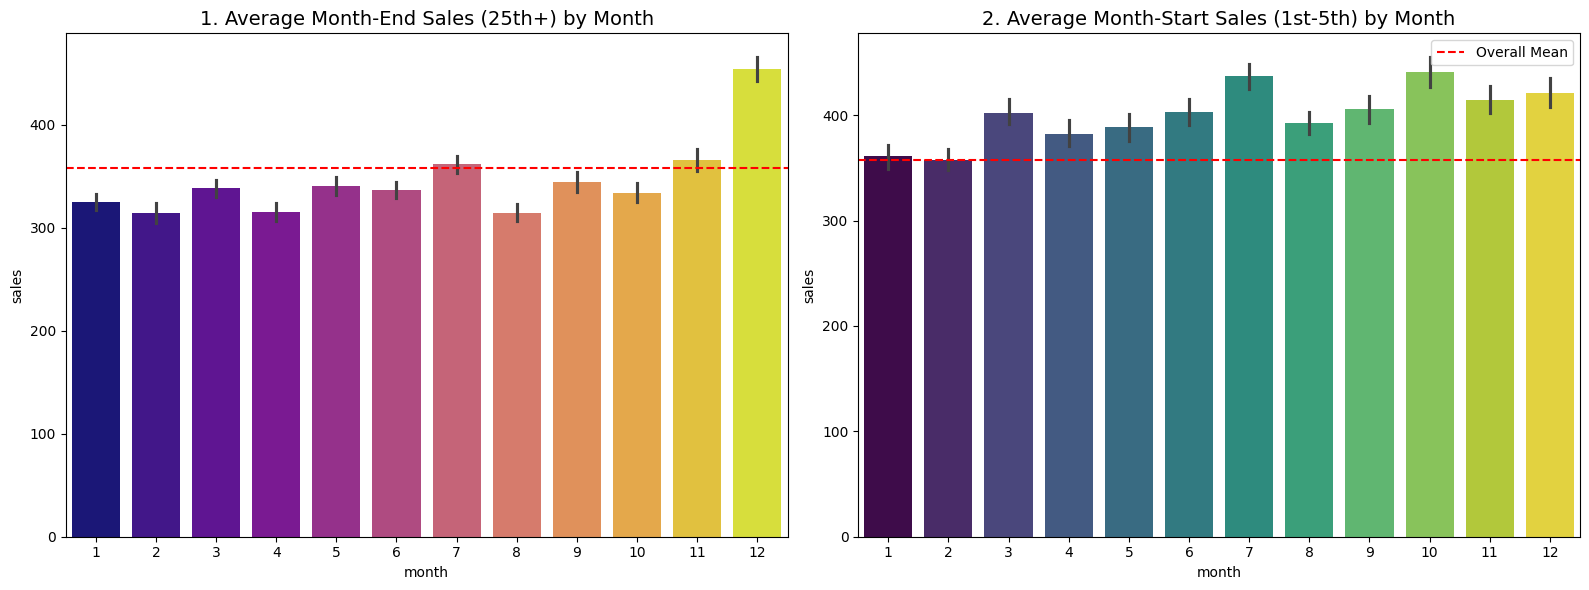

In [7]:
def analyze_monthly_trends(df):
    # Extract month
    df['month'] = df['date'].dt.month
    day = df['date'].dt.day

    # Filter for Month End (25+) and Month Start (1-5)
    df_end = df[day >= 25].copy()
    df_start = df[day <= 5].copy()

    return df_end, df_start

df_end, df_start = analyze_monthly_trends(df)

plt.figure(figsize=(16, 6))

# Plot 1: Month End Sales by Month
plt.subplot(1, 2, 1)
sns.barplot(data=df_end, x='month', y='sales', hue='month', legend=False, palette='plasma')
plt.title('1. Average Month-End Sales (25th+) by Month', fontsize=14)
plt.axhline(df['sales'].mean(), color='red', linestyle='--', label='Overall Mean')

# Plot 2: Month Start Sales by Month
plt.subplot(1, 2, 2)
sns.barplot(data=df_start, x='month', y='sales', hue='month', legend=False, palette='viridis')
plt.title('2. Average Month-Start Sales (1st-5th) by Month', fontsize=14)
plt.axhline(df['sales'].mean(), color='red', linestyle='--', label='Overall Mean')

plt.legend()
plt.tight_layout()
plt.show()

## Store Structure & Maturity

Static attributes like `city` or `type` provide a baseline, but they don't capture the evolution of a store. Our analysis shows that **Store Maturity** is a hidden but dominant factor in sales performance.

* **The Concept of Store Maturity (`log_days_elapsed`):**  

  By calculating the "True Opening Date" (the first date with non-zero sales), we found a wide gap in store ages. For example, while veterans like **Store 1** have been operating for over **1,600 days**, newcomers like **Store 52** joined the network only **117 days** before the end of the training set.  

  We introduced `log_days_elapsed` to quantify this maturity. We used a **logarithmic scale**—$\log(Days\_Elapsed + 1)$—to handle the diminishing returns of age: the difference between 10 and 100 days is a significant growth phase, whereas the difference between 1510 and 1600 days represents a stable, mature state.

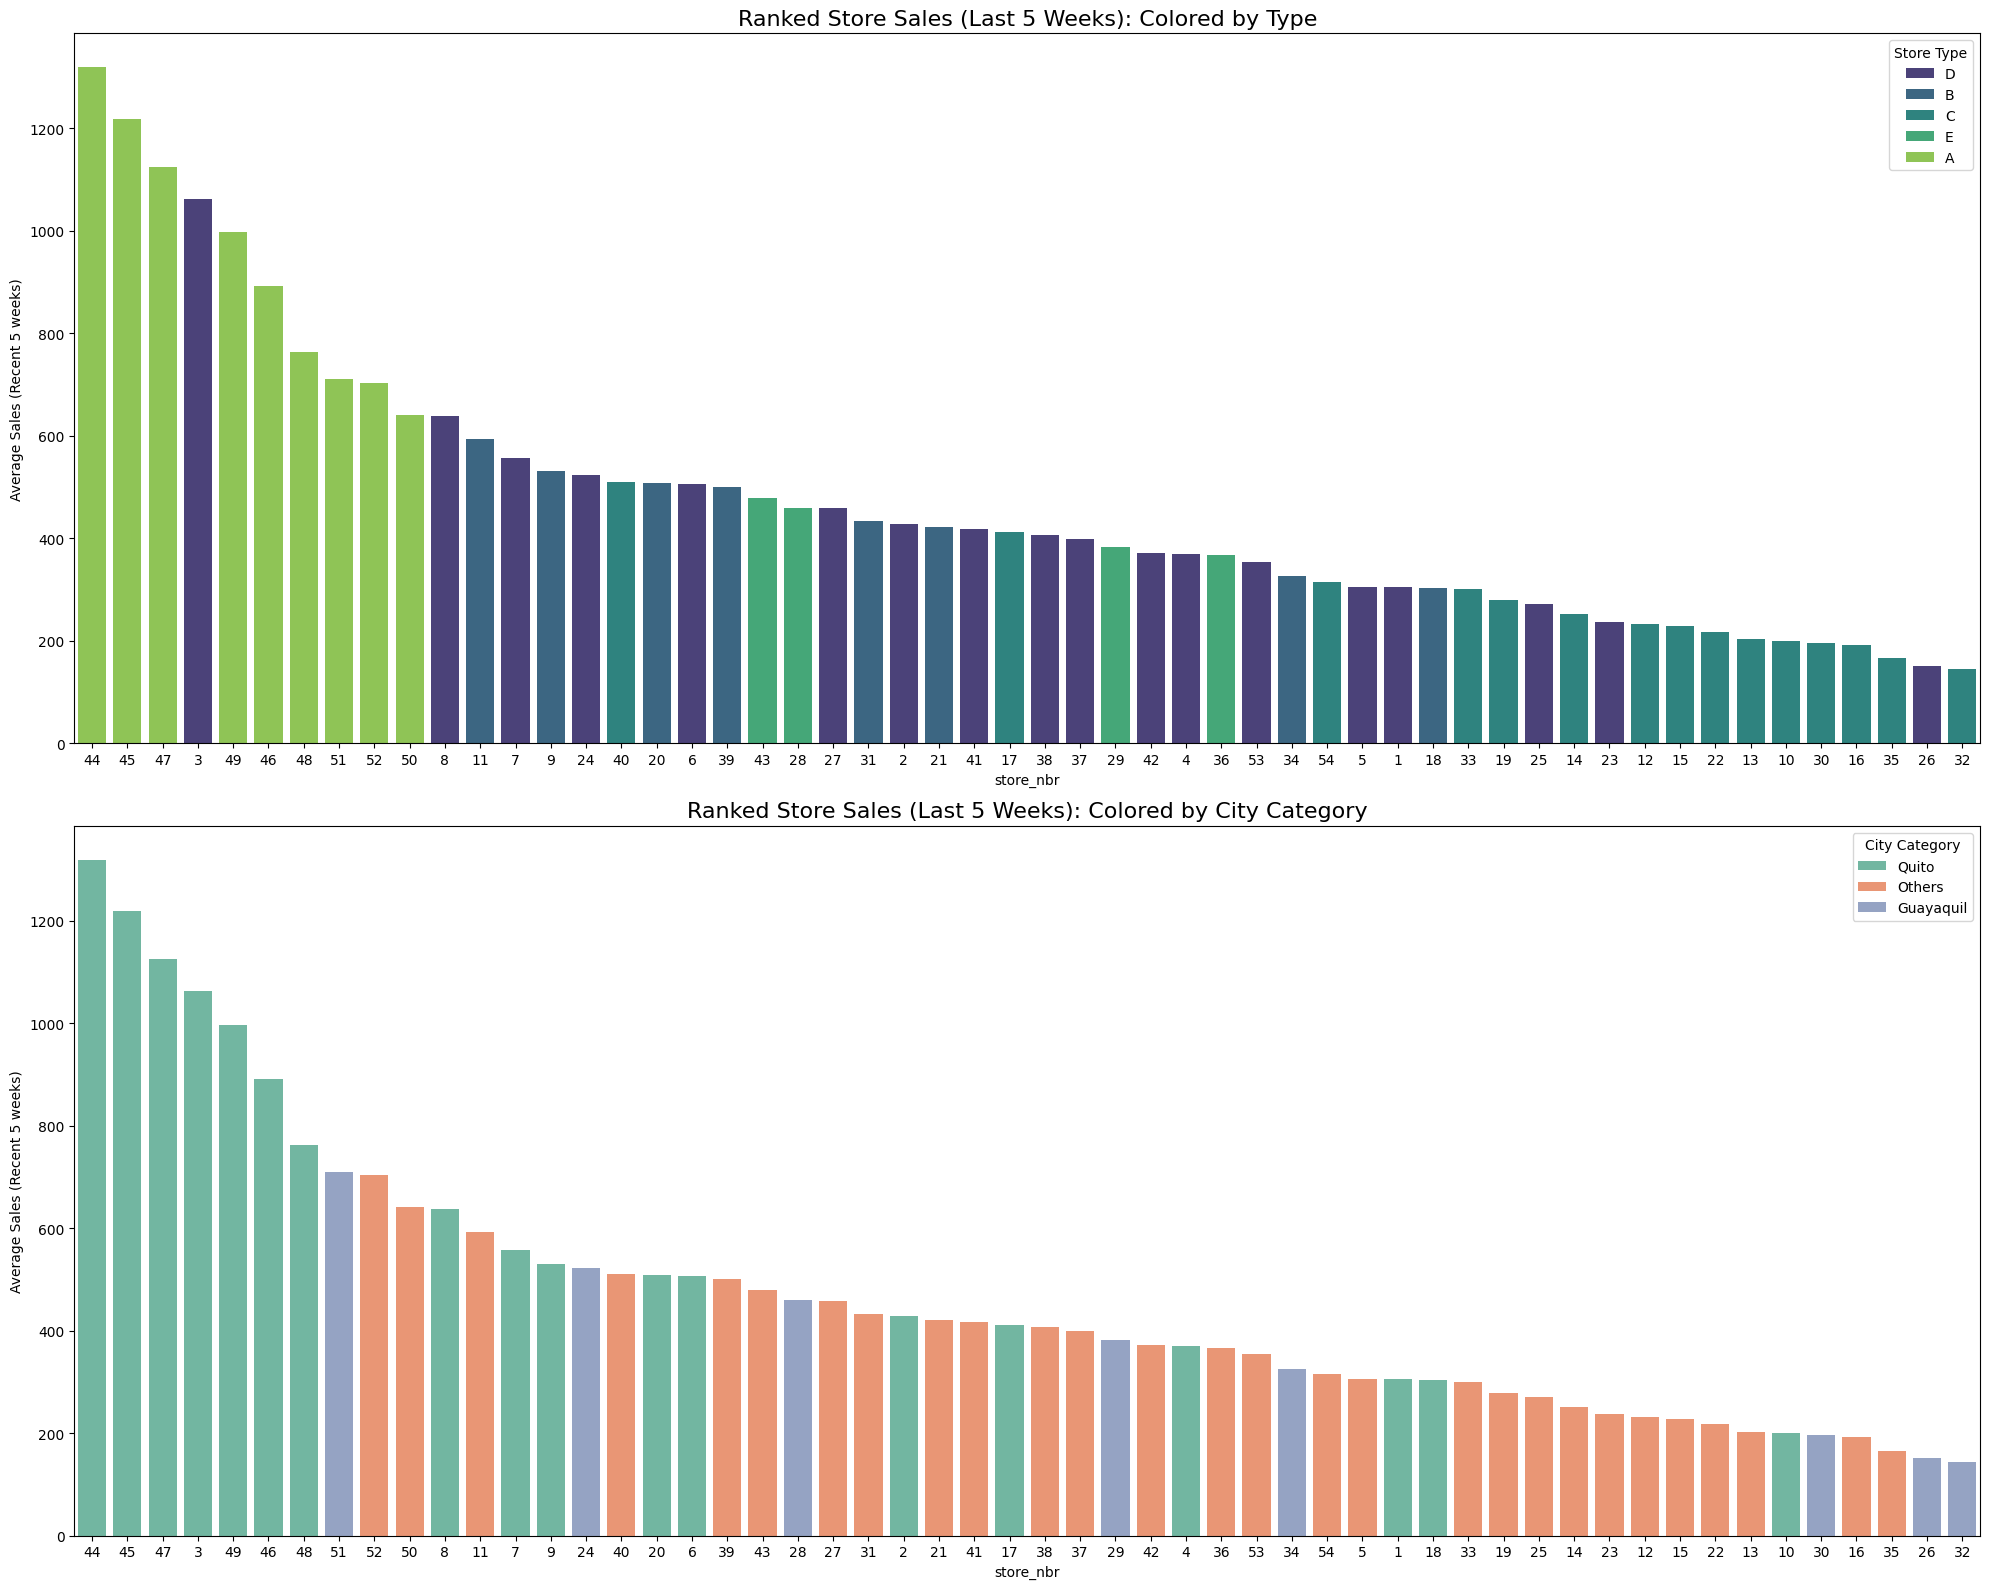

In [8]:
train = pd.read_csv('train.csv', parse_dates=['date'])
stores = pd.read_csv('stores.csv')

# Filter for Last 5 Weeks (There are some shops that recently opened)
# Get the last date in train and calculate the cutoff (5 weeks back)
last_date = train['date'].max()
cutoff_date = last_date - pd.Timedelta(weeks=5)
train_recent = train[train['date'] > cutoff_date].copy()

# Calculate mean sales per store in the last 5 weeks
recent_store_sales = train_recent.groupby('store_nbr')['sales'].mean().reset_index()
recent_store_sales = recent_store_sales.merge(stores, on='store_nbr')

# Define City Category: Quito, Guayaquil, or Others
def categorize_city(city):
    if city == 'Quito': return 'Quito'
    if city == 'Guayaquil': return 'Guayaquil'
    return 'Others'

recent_store_sales['city_cat'] = recent_store_sales['city'].apply(categorize_city)

# Sort by sales for ranking
recent_store_sales = recent_store_sales.sort_values('sales', ascending=False)

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 16))

# Plot 1: Ranked by Store Type
sns.barplot(data=recent_store_sales, x='store_nbr', y='sales', hue='type',
            dodge=False, palette='viridis', order=recent_store_sales['store_nbr'], ax=ax1)
ax1.set_title('Ranked Store Sales (Last 5 Weeks): Colored by Type', fontsize=16)
ax1.set_ylabel('Average Sales (Recent 5 weeks)')
ax1.legend(title='Store Type')

# Plot 2: Ranked by City Category
sns.barplot(data=recent_store_sales, x='store_nbr', y='sales', hue='city_cat',
            dodge=False, palette='Set2', order=recent_store_sales['store_nbr'], ax=ax2)
ax2.set_title('Ranked Store Sales (Last 5 Weeks): Colored by City Category', fontsize=16)
ax2.set_ylabel('Average Sales (Recent 5 weeks)')
ax2.legend(title='City Category')

plt.tight_layout()
plt.show()

In [9]:
# Calculate REAL Days Since Opening
# 1. Filter only rows where sales > 0 to find the actual first day of business
# (Actually, some stores might start with 0, but usually first non-zero is safer)
true_openings = train[train['sales'] > 0].groupby('store_nbr')['date'].min().reset_index()
true_openings.columns = ['store_nbr', 'opening_date']

# 2. Get the last date of the training data
last_train_date = train['date'].max()

# 3. Calculate elapsed days
true_openings['days_elapsed'] = (last_train_date - true_openings['opening_date']).dt.days

print(f"{'Store':<6} | {'True Opening':<12} | {'Days Elapsed'}")
print("-" * 40)

# Merge with a complete list of 1-54 just in case
all_stores = pd.DataFrame({'store_nbr': range(1, 55)})
result = all_stores.merge(true_openings, on='store_nbr', how='left')

for index, row in result.iterrows():
    opening = str(row['opening_date'].date()) if pd.notnull(row['opening_date']) else "Unknown"
    elapsed = str(int(row['days_elapsed'])) if pd.notnull(row['days_elapsed']) else "N/A"
    print(f"{int(row['store_nbr']):<6} | {opening:<12} | {elapsed} days")

Store  | True Opening | Days Elapsed
----------------------------------------
1      | 2013-01-02   | 1686 days
2      | 2013-01-02   | 1686 days
3      | 2013-01-02   | 1686 days
4      | 2013-01-02   | 1686 days
5      | 2013-01-02   | 1686 days
6      | 2013-01-02   | 1686 days
7      | 2013-01-02   | 1686 days
8      | 2013-01-02   | 1686 days
9      | 2013-01-02   | 1686 days
10     | 2013-01-02   | 1686 days
11     | 2013-01-02   | 1686 days
12     | 2013-01-02   | 1686 days
13     | 2013-01-02   | 1686 days
14     | 2013-01-02   | 1686 days
15     | 2013-01-02   | 1686 days
16     | 2013-01-02   | 1686 days
17     | 2013-01-02   | 1686 days
18     | 2013-01-02   | 1686 days
19     | 2013-01-02   | 1686 days
20     | 2015-02-13   | 914 days
21     | 2015-07-24   | 753 days
22     | 2015-10-09   | 676 days
23     | 2013-01-02   | 1686 days
24     | 2013-01-02   | 1686 days
25     | 2013-01-01   | 1687 days
26     | 2013-01-02   | 1686 days
27     | 2013-01-02   | 1686 days
28     

## Promotion Strategy

While promotions are a primary driver of sales, their impact is not uniform.

* **Direct Promotion Count (`onpromotion`):**  

  This is the raw count of items under promotion within a specific category. Since promotion schedules are pre-determined by the business, this serves as a reliable lead indicator of upcoming sales spikes.

* **Promotion Share:**  

  We calculated the `promo_share`—the ratio of a category's promotions relative to the total promotions occurring in that store on the same day.  

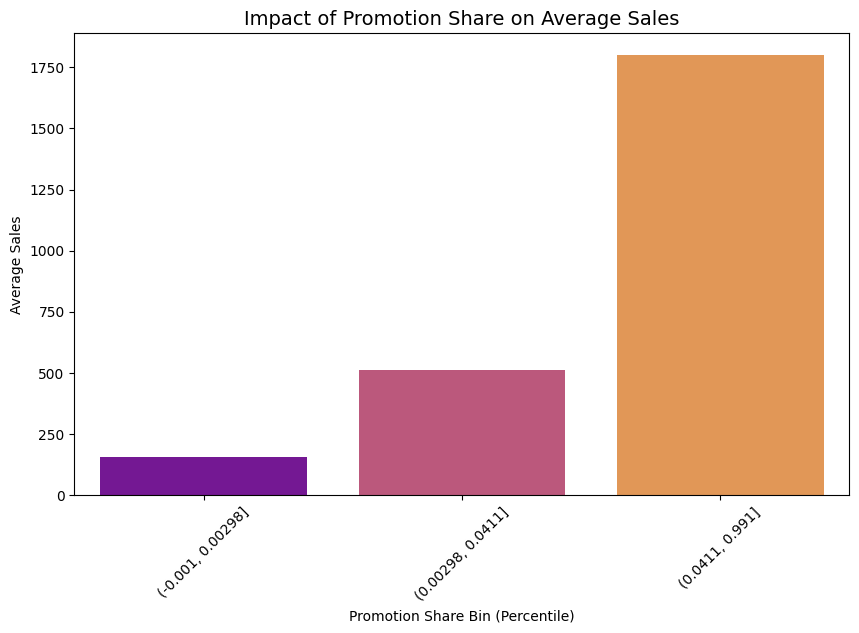

In [10]:
# Calculate daily total promotions per store
store_daily_promo = train.groupby(['date', 'store_nbr'])['onpromotion'].sum().reset_index()
store_daily_promo.columns = ['date', 'store_nbr', 'total_promo_store']

# Merge back to original train
train_promo = train.merge(store_daily_promo, on=['date', 'store_nbr'], how='left')

# Calculate promotion share for each category
# Avoid division by zero
train_promo['promo_share'] = train_promo['onpromotion'] / (train_promo['total_promo_store'] + 1)

# Group by promo_share bins to see the impact on sales
train_promo['promo_bin'] = pd.qcut(train_promo['promo_share'], q=10, duplicates='drop')
promo_impact = train_promo.groupby('promo_bin', observed=False)['sales'].mean().reset_index()

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=promo_impact, x='promo_bin', y='sales', hue='promo_bin', legend=False, palette='plasma')
plt.title('Impact of Promotion Share on Average Sales', fontsize=14)
plt.xlabel('Promotion Share Bin (Percentile)')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()

# **Feature Engineering**

In [11]:
# Load datasets
train = pd.read_csv('train.csv', parse_dates=['date'])
test = pd.read_csv('test.csv', parse_dates=['date'])
stores = pd.read_csv('stores.csv')
oil = pd.read_csv('oil.csv', parse_dates=['date'])
holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])

In [12]:
def create_final_features(df, train_source, stores_df, oil_df, holidays_df):

    df = df.merge(stores_df, on='store_nbr', how='left')

    # 1. Holidays: Keep as original simple model but ensure no duplicates
    h_data = holidays_df[(holidays_df['type'] != 'Work Day') & (holidays_df['transferred'] == False)]
    h_data = h_data[['date', 'type']].rename(columns={'type': 'holiday_type'})
    h_data = h_data.drop_duplicates(subset=['date'])
    df = df.merge(h_data, on='date', how='left')
    df['holiday_type'] = df['holiday_type'].fillna('None')

    # 2. Store Maturity (log_days_elapsed)
    opening_dates = train_source[train_source['sales'] > 0].groupby('store_nbr')['date'].min().reset_index()
    opening_dates.columns = ['store_nbr', 'opening_date']
    df = df.merge(opening_dates, on='store_nbr', how='left')
    df['log_days_elapsed'] = np.log1p((df['date'] - df['opening_date']).dt.days.clip(lower=0))
    df['log_days_elapsed'] = df['log_days_elapsed'].fillna(0)

    # 3. Promotion Features
    daily_store_promo = df.groupby(['date', 'store_nbr'])['onpromotion'].transform('sum')
    df['promo_share'] = df['onpromotion'] / (daily_store_promo + 1)

    # 4. Date Components
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # 5. Special Flags
    df['is_jan_1st'] = ((df['date'].dt.month == 1) & (df['date'].dt.day == 1)).astype(int)

    df['month_cycle'] = 'Other'
    df.loc[df['date'].dt.day <= 5, 'month_cycle'] = 'Month-Start'
    df.loc[df['date'].dt.day >= 25, 'month_cycle'] = 'Month-End'

    # 6. Set Categorical Types
    cat_cols = ['family', 'city', 'state', 'type', 'holiday_type', 'month_cycle']
    for col in cat_cols:
        df[col] = df[col].astype('category')

    return df

# Apply processing
train_df = create_final_features(train, train, stores, oil, holidays)
test_df = create_final_features(test, train, stores, oil, holidays)

# **Model Training**

## **Model Training & Feature Validation**

To prove the effectiveness of the **Store Maturity** hypothesis, we conducted a comparative experiment: training a baseline model and then adding `log_days_elapsed` to see the delta in performance.

### The Experiment: Baseline vs. Maturity Model

| Feature Set | Validation RMSE (Log Scale) | Improvement |
|:---|:---:|:---:|
| **Baseline** (Standard Features) | **0.448953** | - |
| **Maturity Model** (+ `log_days_elapsed`) | **0.414793** | **+7.6% (0.03416)** |

###  Key Insights from Feature Importance

The inclusion of `log_days_elapsed` led to a fascinating shift in how the model understands the data:

* **Instant Dominance:**  

  As soon as it was introduced, `log_days_elapsed` became the **#2 feature** (Importance: ~9,800), sitting right behind the product `family`.  

* **Replacing "Year":**  
  In the baseline, the raw `year` feature was the #2 predictor. However, in the Maturity Model, the importance of `year` plummeted from **~7,800 to ~2,200**.

In [13]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.205798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 681
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 16
[LightGBM] [Info] Start training from score 2.920052
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1999]	valid_0's rmse: 0.448953	valid_0's l2: 0.201559
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.202003 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 936
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 17
[LightGBM] [Info] Start training from score 2.920052
Training until validat

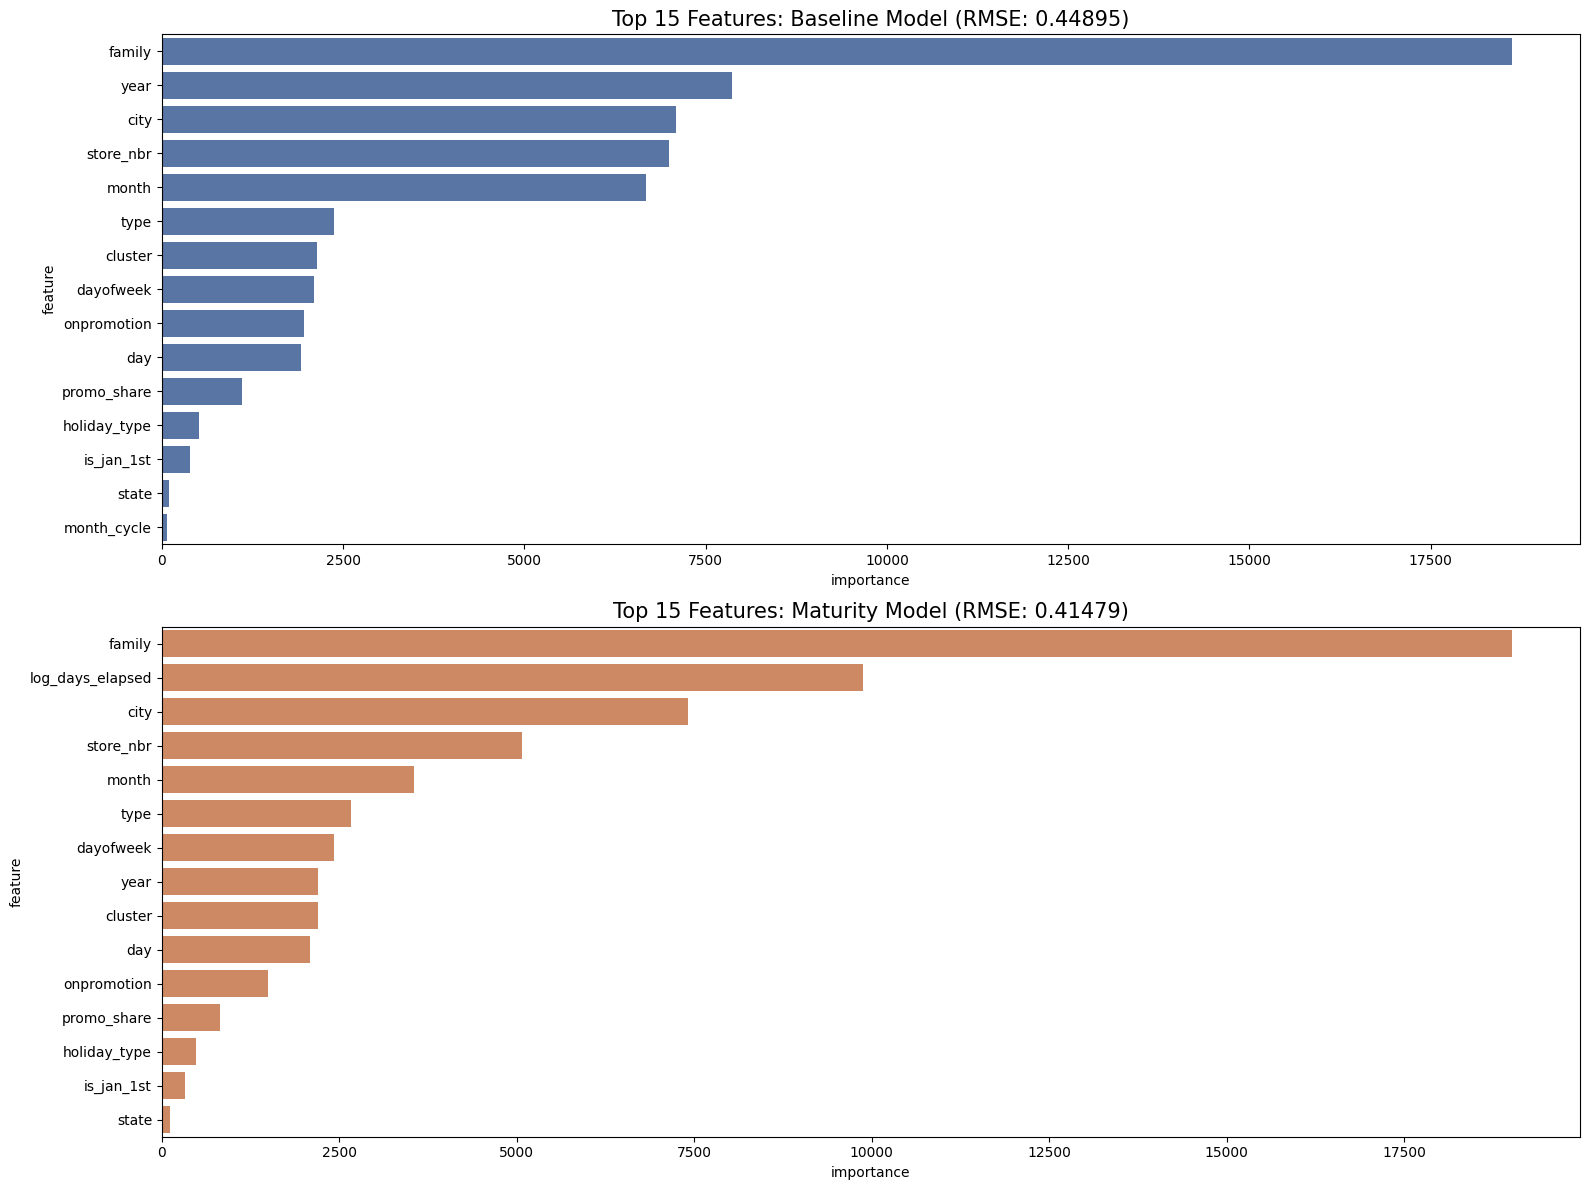


Summary Table:
1. Baseline RMSE: 0.448953
2. Maturity RMSE: 0.414793
Improvement: 0.034160


In [14]:
def train_and_get_importance(train_df, features, model_name, target='sales'):
    # Prepare Data
    y = np.log1p(train_df[target])
    X = train_df[features]

    # Time-Series Split
    X_train = X[train_df['date'] < '2017-08-01']
    y_train = y[train_df['date'] < '2017-08-01']
    X_val = X[train_df['date'] >= '2017-08-01']
    y_val = y[train_df['date'] >= '2017-08-01']

    # Initialize and train
    model = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.05, random_state=42)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
    )

    # Get Results
    rmse = model.best_score_['valid_0']['rmse']
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_,
        'model': model_name
    })

    return rmse, importance_df

# --- Define Feature Sets ---
base_feats = [
    'store_nbr', 'family', 'city', 'state', 'type', 'cluster',
    'year', 'month', 'day', 'dayofweek', 'is_weekend', 'holiday_type',
    'onpromotion', 'promo_share', 'is_jan_1st', 'month_cycle'
]
maturity_feats = base_feats + ['log_days_elapsed']

# --- Execute Training ---
rmse_1, imp_1 = train_and_get_importance(train_df, base_feats, 'Baseline (Without Maturity)')
rmse_2, imp_2 = train_and_get_importance(train_df, maturity_feats, 'Maturity Model (With log_days_elapsed)')

# --- Visualization ---
plt.figure(figsize=(16, 12))

# Subplot 1: Baseline Importance
plt.subplot(2, 1, 1)
sns.barplot(data=imp_1.sort_values('importance', ascending=False).head(15), 
            x='importance', y='feature', color='#4C72B0')
plt.title(f'Top 15 Features: Baseline Model (RMSE: {rmse_1:.5f})', fontsize=15)

# Subplot 2: Maturity Model Importance
plt.subplot(2, 1, 2)
sns.barplot(data=imp_2.sort_values('importance', ascending=False).head(15), 
            x='importance', y='feature', color='#DD8452')
plt.title(f'Top 15 Features: Maturity Model (RMSE: {rmse_2:.5f})', fontsize=15)

plt.tight_layout()
plt.show()

print(f"\nSummary Table:")
print(f"1. Baseline RMSE: {rmse_1:.6f}")
print(f"2. Maturity RMSE: {rmse_2:.6f}")
print(f"Improvement: {rmse_1 - rmse_2:.6f}")

# **Submission**

In [15]:
# --- 1. Settings ---
features = [
    'store_nbr', 'family', 'city', 'state', 'type', 'cluster',
    'year', 'month', 'day', 'dayofweek', 'is_weekend', 'holiday_type',
    'onpromotion', 'promo_share', 'is_jan_1st', 'month_cycle',
    'log_days_elapsed'
]
target = 'sales'

# --- 2. Training on Full Data ---
# Using the best iteration (1996) found in our validation experiments
print("Retraining model on full dataset...")
y_full = np.log1p(train_df[target])
X_full = train_df[features]

final_model = lgb.LGBMRegressor(n_estimators=1996, learning_rate=0.05, random_state=42)
final_model.fit(X_full, y_full)

# --- 3. Prediction ---
print("Predicting on test data...")
test_preds = final_model.predict(test_df[features])

# Reverse Log Transformation & Clip negative values
final_preds = np.expm1(test_preds)
final_preds = np.maximum(final_preds, 0)

# --- 4. Create Submission File ---
submission = pd.DataFrame({
    'id': test['id'],
    'sales': final_preds
})
filename = 'submission.csv'
submission.to_csv(filename, index=False)
print(f"File created: {filename}")

# --- 5. Kaggle API Submission ---
competition_name = "store-sales-time-series-forecasting"
message = "Submission: Store Maturity model with Public Score 0.42599 target"

# print(f"Submitting to Kaggle competition: {competition_name}...")
# submit_cmd = f'kaggle competitions submit -c {competition_name} -f {filename} -m "{message}"'

# !kaggle competitions submit -c {competition_name} -f {filename} -m "{message}"

Retraining model on full dataset...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.199832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 937
[LightGBM] [Info] Number of data points in the train set: 3000888, number of used features: 17
[LightGBM] [Info] Start training from score 2.926368
Predicting on test data...
File created: submission.csv
